# Temperature Scaling — Post-Hoc Calibration (Fixed)

**Goal:** Apply temperature scaling to KanResWideX and CNN-BiLSTM to reduce overconfidence.

**Important:** Since only the best fold's model was saved, temperature T is learned exclusively from that fold's validation set (the only true out-of-sample data). The temperature is then applied to PTB-XL and Georgia for cross-dataset evaluation.

### Method:
1. Identify the true validation fold (the fold the saved model was NOT trained on)
2. Learn optimal T on that fold's validation logits
3. Apply T to cross-dataset predictions (PTB-XL + Georgia)


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install wfdb -q
print('Ready.')

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 140.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
Ready.


## 1. Imports

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import minimize_scalar
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import wfdb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Configuration

In [3]:
class Config:
    afib_dir = ""
    normal_dir = ""
    kanres_model_path = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_model_12lead.pth"
    bilstm_model_path = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/Best model/best_cnn_bilstm_12lead.pth"
    fs = 500
    num_channels = 12
    recording_seconds = 10
    recording_samples = fs * recording_seconds
    batch_size = 128
    num_classes = 2
    n_folds = 5
    random_seed = 42
    pdf_dir = "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_temperature_scaling"

config = Config()
assert os.path.exists(config.kanres_model_path), "KanResWideX model not found"
assert os.path.exists(config.bilstm_model_path), "CNN-BiLSTM model not found"
os.makedirs(config.pdf_dir, exist_ok=True)
print("Config ready.")

Config ready.


## 3. Unzip Chapman-Shaoxing

In [4]:
if not os.path.exists("/content/subset_data"):
    print("Unzipping Chapman-Shaoxing...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/afib_normal_subset_ecg_arrhythmia.zip" -d /content/subset_data/

for base in ["/content/subset_data", "/content/subset_data/afib_normal_subset",
             "/content/subset_data/afib_normal_subset_ecg_arrhythmia"]:
    if os.path.exists(os.path.join(base, "afib")):
        config.afib_dir = os.path.join(base, "afib")
        config.normal_dir = os.path.join(base, "normal")
        break

print(f"AFib: {len([f for f in os.listdir(config.afib_dir) if f.endswith('.hea')])} records")
print(f"Normal: {len([f for f in os.listdir(config.normal_dir) if f.endswith('.hea')])} records")

Unzipping Chapman-Shaoxing...
AFib: 1780 records
Normal: 8125 records


## 4. Model Definitions

In [5]:
class KanResInit(nn.Module):
    def __init__(self, in_channels, f1, f2, k1, k2, s):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, f1, k1, stride=s)
        self.bn1 = nn.BatchNorm1d(f1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(f1, f2, k2)
        self.bn2 = nn.BatchNorm1d(f2)
        self.relu2 = nn.ReLU()
    def forward(self, x):
        return self.relu2(self.bn2(self.conv2(self.relu1(self.bn1(self.conv1(x))))))

class KanResModule(nn.Module):
    def __init__(self, in_c, f1, f2, k1, k2, s):
        super().__init__()
        self.conv1 = nn.Conv1d(in_c, f1, k1, stride=s, padding='same')
        self.bn1 = nn.BatchNorm1d(f1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(f1, f2, k2, padding='same')
        self.bn2 = nn.BatchNorm1d(f2)
        self.relu2 = nn.ReLU()
    def forward(self, x):
        return self.relu2(self.bn2(self.conv2(self.relu1(self.bn1(self.conv1(x)))))) + x

class KanResWideX(nn.Module):
    def __init__(self, input_channels=12, output_size=2):
        super().__init__()
        self.init_block = KanResInit(input_channels, 64, 32, 8, 3, 1)
        self.pool = nn.AvgPool1d(2)
        self.res_modules = nn.ModuleList([KanResModule(32, 64, 32, 50, 50, 1) for _ in range(8)])
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(32, output_size)
    def forward(self, x):
        x = self.pool(self.init_block(x))
        for m in self.res_modules: x = m(x)
        return self.fc(self.global_pool(x).squeeze(-1))

class CNNBiLSTM(nn.Module):
    def __init__(self, input_channels=12, output_size=2):
        super().__init__()
        self.cnn1 = nn.Sequential(nn.Conv1d(input_channels, 64, 7, padding=3), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(3), nn.Dropout(0.2))
        self.cnn2 = nn.Sequential(nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.2))
        self.cnn3 = nn.Sequential(nn.Conv1d(128, 256, 3, padding=1), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.3))
        self.bilstm1 = nn.LSTM(256, 128, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(0.3)
        self.bilstm2 = nn.LSTM(256, 64, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(0.3)
        self.classifier = nn.Sequential(nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4), nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, output_size))
    def forward(self, x):
        x = self.cnn3(self.cnn2(self.cnn1(x))).permute(0, 2, 1)
        x, _ = self.bilstm1(x); x = self.dropout1(x)
        x, _ = self.bilstm2(x); x = self.dropout2(x)
        return self.classifier(x[:, -1, :])

print("Models defined.")

Models defined.


## 5. Helper Functions

In [6]:
def load_record(rec, config):
    try:
        r = wfdb.rdrecord(rec["path"])
        sig = r.p_signal
    except: return None, None
    if sig.shape[1] < config.num_channels or np.any(np.isnan(sig)): return None, None
    if len(sig) < config.recording_samples:
        sig = np.vstack([sig, np.zeros((config.recording_samples - len(sig), config.num_channels))])
    elif len(sig) > config.recording_samples:
        sig = sig[:config.recording_samples, :]
    for ch in range(config.num_channels):
        std = np.std(sig[:, ch])
        if std < 1e-6: sig[:, ch] = np.random.normal(0, 1e-4, len(sig[:, ch]))
        else: sig[:, ch] = (sig[:, ch] - np.mean(sig[:, ch])) / std
    return sig[:, :config.num_channels].T.copy().astype(np.float32), np.int64(rec["label"])

class ECGDataset(Dataset):
    def __init__(self, s, l):
        self.s = torch.FloatTensor(s); self.l = torch.LongTensor(l)
    def __len__(self): return len(self.l)
    def __getitem__(self, i): return self.s[i], self.l[i]

def get_logits_and_labels(model, loader, device):
    model.eval()
    logits_all, labels_all = [], []
    with torch.no_grad():
        for x, y in loader:
            logits_all.append(model(x.to(device)).cpu())
            labels_all.append(y)
    return torch.cat(logits_all), torch.cat(labels_all)

def find_optimal_temperature(logits, labels):
    def nll(T):
        return nn.functional.nll_loss(nn.functional.log_softmax(logits / T, dim=1), labels).item()
    return minimize_scalar(nll, bounds=(0.1, 10.0), method='bounded').x

def apply_temperature(logits, T):
    return torch.softmax(logits / T, dim=1)[:, 1].numpy()

def compute_calibration(targets, probs):
    n_bins = 10
    boundaries = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    for i in range(n_bins):
        mask = (probs >= boundaries[i]) & (probs < boundaries[i+1]) if i < n_bins-1 else (probs >= boundaries[i]) & (probs <= boundaries[i+1])
        if mask.sum() > 0:
            err = abs(targets[mask].mean() - probs[mask].mean())
            ece += (mask.sum() / len(targets)) * err
            mce = max(mce, err)
    return {"ece": ece, "mce": mce, "brier": brier_score_loss(targets, probs)}

def compute_all_metrics(targets, preds, probs):
    cm = confusion_matrix(targets, preds, labels=[0,1])
    tn,fp,fn,tp = cm.ravel()
    cal = compute_calibration(targets, probs)
    return {"accuracy": accuracy_score(targets, preds), "precision": precision_score(targets, preds, zero_division=0),
            "recall": recall_score(targets, preds, zero_division=0), "f1": f1_score(targets, preds, zero_division=0),
            "mcc": matthews_corrcoef(targets, preds), "auroc": roc_auc_score(targets, probs),
            "auprc": average_precision_score(targets, probs), "tn":tn, "fp":fp, "fn":fn, "tp":tp, **cal, "cm": cm}

print("Functions defined.")

Functions defined.


## 6. Load Chapman-Shaoxing & Recreate Split

In [7]:
# Discover and load records
afib_files = sorted([f[:-4] for f in os.listdir(config.afib_dir) if f.endswith('.hea')])
normal_files = sorted([f[:-4] for f in os.listdir(config.normal_dir) if f.endswith('.hea')])
all_records = []
for n in afib_files: all_records.append({"path": os.path.join(config.afib_dir, n), "name": n, "label": 1})
for n in normal_files: all_records.append({"path": os.path.join(config.normal_dir, n), "name": n, "label": 0})

print(f"Loading {len(all_records)} records...")
start = time.time()
patient_data = {}
for i, rec in enumerate(all_records):
    if (i+1) % 2000 == 0: print(f"  {i+1}/{len(all_records)} ({time.time()-start:.0f}s)")
    s, l = load_record(rec, config)
    if s is not None: patient_data[rec["name"]] = {"sample": s, "label": l}
print(f"Loaded: {len(patient_data)} patients")

# Recreate same split
np.random.seed(config.random_seed)
patient_names = np.array(sorted(patient_data.keys()))
patient_labels = np.array([patient_data[p]["label"] for p in patient_names])
skf = StratifiedKFold(n_splits=config.n_folds, shuffle=True, random_state=config.random_seed)
folds = []
for ti, vi in skf.split(patient_names, patient_labels):
    folds.append({"train": patient_names[ti].tolist(), "val": patient_names[vi].tolist()})

def merge_patients(plist):
    s = np.array([patient_data[p]["sample"] for p in plist], dtype=np.float32)
    l = np.array([patient_data[p]["label"] for p in plist], dtype=np.int64)
    return s, l

print(f"5-fold split recreated (seed={config.random_seed})")

Loading 9905 records...
  2000/9905 (20s)
  4000/9905 (40s)
  6000/9905 (60s)
  8000/9905 (80s)
Loaded: 9889 patients
5-fold split recreated (seed=42)


## 7. Identify True Validation Fold & Learn Temperature

The saved model was the best fold model. When applied to other folds, it sees its own training data (artificially perfect results). We identify the true validation fold by finding the fold with the lowest accuracy — that's the one the model was NOT trained on.

In [8]:
all_results = {}

for model_name, model_path, ModelClass in [
    ("KanResWideX", config.kanres_model_path, KanResWideX),
    ("CNN-BiLSTM", config.bilstm_model_path, CNNBiLSTM)
]:
    print(f"\n{'='*70}")
    print(f"{model_name}")
    print(f"{'='*70}")

    model = ModelClass(input_channels=config.num_channels, output_size=config.num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # Find true validation fold (lowest accuracy = not in training data)
    fold_accs = []
    fold_data = []
    for fold_idx, fold in enumerate(folds):
        X_val, y_val = merge_patients(fold["val"])
        loader = DataLoader(ECGDataset(X_val, y_val), batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)
        logits, labels = get_logits_and_labels(model, loader, device)
        probs = torch.softmax(logits, dim=1)[:, 1].numpy()
        acc = accuracy_score(labels.numpy(), (probs >= 0.5).astype(int))
        fold_accs.append(acc)
        fold_data.append({"logits": logits, "labels": labels, "probs": probs, "targets": labels.numpy()})
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}")

    # True validation fold = lowest accuracy
    true_fold = np.argmin(fold_accs)
    print(f"\n  True validation fold: Fold {true_fold+1} (Acc={fold_accs[true_fold]:.4f})")
    print(f"  Other folds are training data (Acc>{min(a for i,a in enumerate(fold_accs) if i!=true_fold):.4f})")

    # Get logits from true validation fold
    val_logits = fold_data[true_fold]["logits"]
    val_labels = fold_data[true_fold]["labels"]
    val_targets = fold_data[true_fold]["targets"]
    val_probs_before = fold_data[true_fold]["probs"]

    # Learn optimal temperature
    T = find_optimal_temperature(val_logits, val_labels)
    print(f"  Optimal temperature: T = {T:.4f}")

    # Apply temperature
    val_probs_after = apply_temperature(val_logits, T)
    val_preds_before = (val_probs_before >= 0.5).astype(int)
    val_preds_after = (val_probs_after >= 0.5).astype(int)

    metrics_before = compute_all_metrics(val_targets, val_preds_before, val_probs_before)
    metrics_after = compute_all_metrics(val_targets, val_preds_after, val_probs_after)

    print(f"\n  Chapman-Shaoxing (Fold {true_fold+1} validation):")
    print(f"    ECE:   {metrics_before['ece']:.4f} -> {metrics_after['ece']:.4f}")
    print(f"    MCE:   {metrics_before['mce']:.4f} -> {metrics_after['mce']:.4f}")
    print(f"    Brier: {metrics_before['brier']:.4f} -> {metrics_after['brier']:.4f}")
    print(f"    Acc:   {metrics_before['accuracy']:.4f} -> {metrics_after['accuracy']:.4f}")

    all_results[model_name] = {
        "T": T, "true_fold": true_fold,
        "chapman_before": metrics_before, "chapman_after": metrics_after,
        "val_probs_before": val_probs_before, "val_probs_after": val_probs_after,
        "val_targets": val_targets, "model": model
    }


KanResWideX
  Fold 1: Acc=1.0000
  Fold 2: Acc=1.0000
  Fold 3: Acc=0.9975
  Fold 4: Acc=1.0000
  Fold 5: Acc=1.0000

  True validation fold: Fold 3 (Acc=0.9975)
  Other folds are training data (Acc>1.0000)
  Optimal temperature: T = 1.0275

  Chapman-Shaoxing (Fold 3 validation):
    ECE:   0.0022 -> 0.0022
    MCE:   0.5736 -> 0.5717
    Brier: 0.0019 -> 0.0019
    Acc:   0.9975 -> 0.9975

CNN-BiLSTM
  Fold 1: Acc=0.9970
  Fold 2: Acc=0.9954
  Fold 3: Acc=0.9990
  Fold 4: Acc=0.9944
  Fold 5: Acc=0.9995

  True validation fold: Fold 4 (Acc=0.9944)
  Other folds are training data (Acc>0.9954)
  Optimal temperature: T = 1.4717

  Chapman-Shaoxing (Fold 4 validation):
    ECE:   0.0051 -> 0.0039
    MCE:   0.6648 -> 0.5160
    Brier: 0.0046 -> 0.0045
    Acc:   0.9944 -> 0.9944


## 8. Chapman-Shaoxing: Before vs After Comparison

In [9]:
print("=" * 80)
print("TEMPERATURE SCALING RESULTS — Chapman-Shaoxing (True Validation Fold)")
print("=" * 80)

for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    r = all_results[model_name]
    print(f"\n--- {model_name} (T = {r['T']:.4f}, Fold {r['true_fold']+1}) ---")
    print(f"{'Metric':<15} {'Before':<15} {'After':<15} {'Change':<15}")
    print("-" * 60)
    for metric in ["accuracy", "precision", "recall", "f1", "auroc", "brier", "ece", "mce"]:
        b = r["chapman_before"][metric]
        a = r["chapman_after"][metric]
        change = a - b
        better = "improved" if (metric in ["brier","ece","mce"] and change < 0) or (metric not in ["brier","ece","mce"] and change > 0) else "degraded" if abs(change) > 0.0001 else "unchanged"
        print(f"{metric.upper():<15} {b:<15.4f} {a:<15.4f} {change:+.4f} ({better})")

TEMPERATURE SCALING RESULTS — Chapman-Shaoxing (True Validation Fold)

--- KanResWideX (T = 1.0275, Fold 3) ---
Metric          Before          After           Change         
------------------------------------------------------------
ACCURACY        0.9975          0.9975          +0.0000 (unchanged)
PRECISION       0.9944          0.9944          +0.0000 (unchanged)
RECALL          0.9916          0.9916          +0.0000 (unchanged)
F1              0.9930          0.9930          +0.0000 (unchanged)
AUROC           0.9999          0.9999          +0.0000 (unchanged)
BRIER           0.0019          0.0019          +0.0000 (unchanged)
ECE             0.0022          0.0022          -0.0000 (improved)
MCE             0.5736          0.5717          -0.0019 (improved)

--- CNN-BiLSTM (T = 1.4717, Fold 4) ---
Metric          Before          After           Change         
------------------------------------------------------------
ACCURACY        0.9944          0.9944          +0.0000

## 9. Calibration Plots: Before vs After (Chapman-Shaoxing)

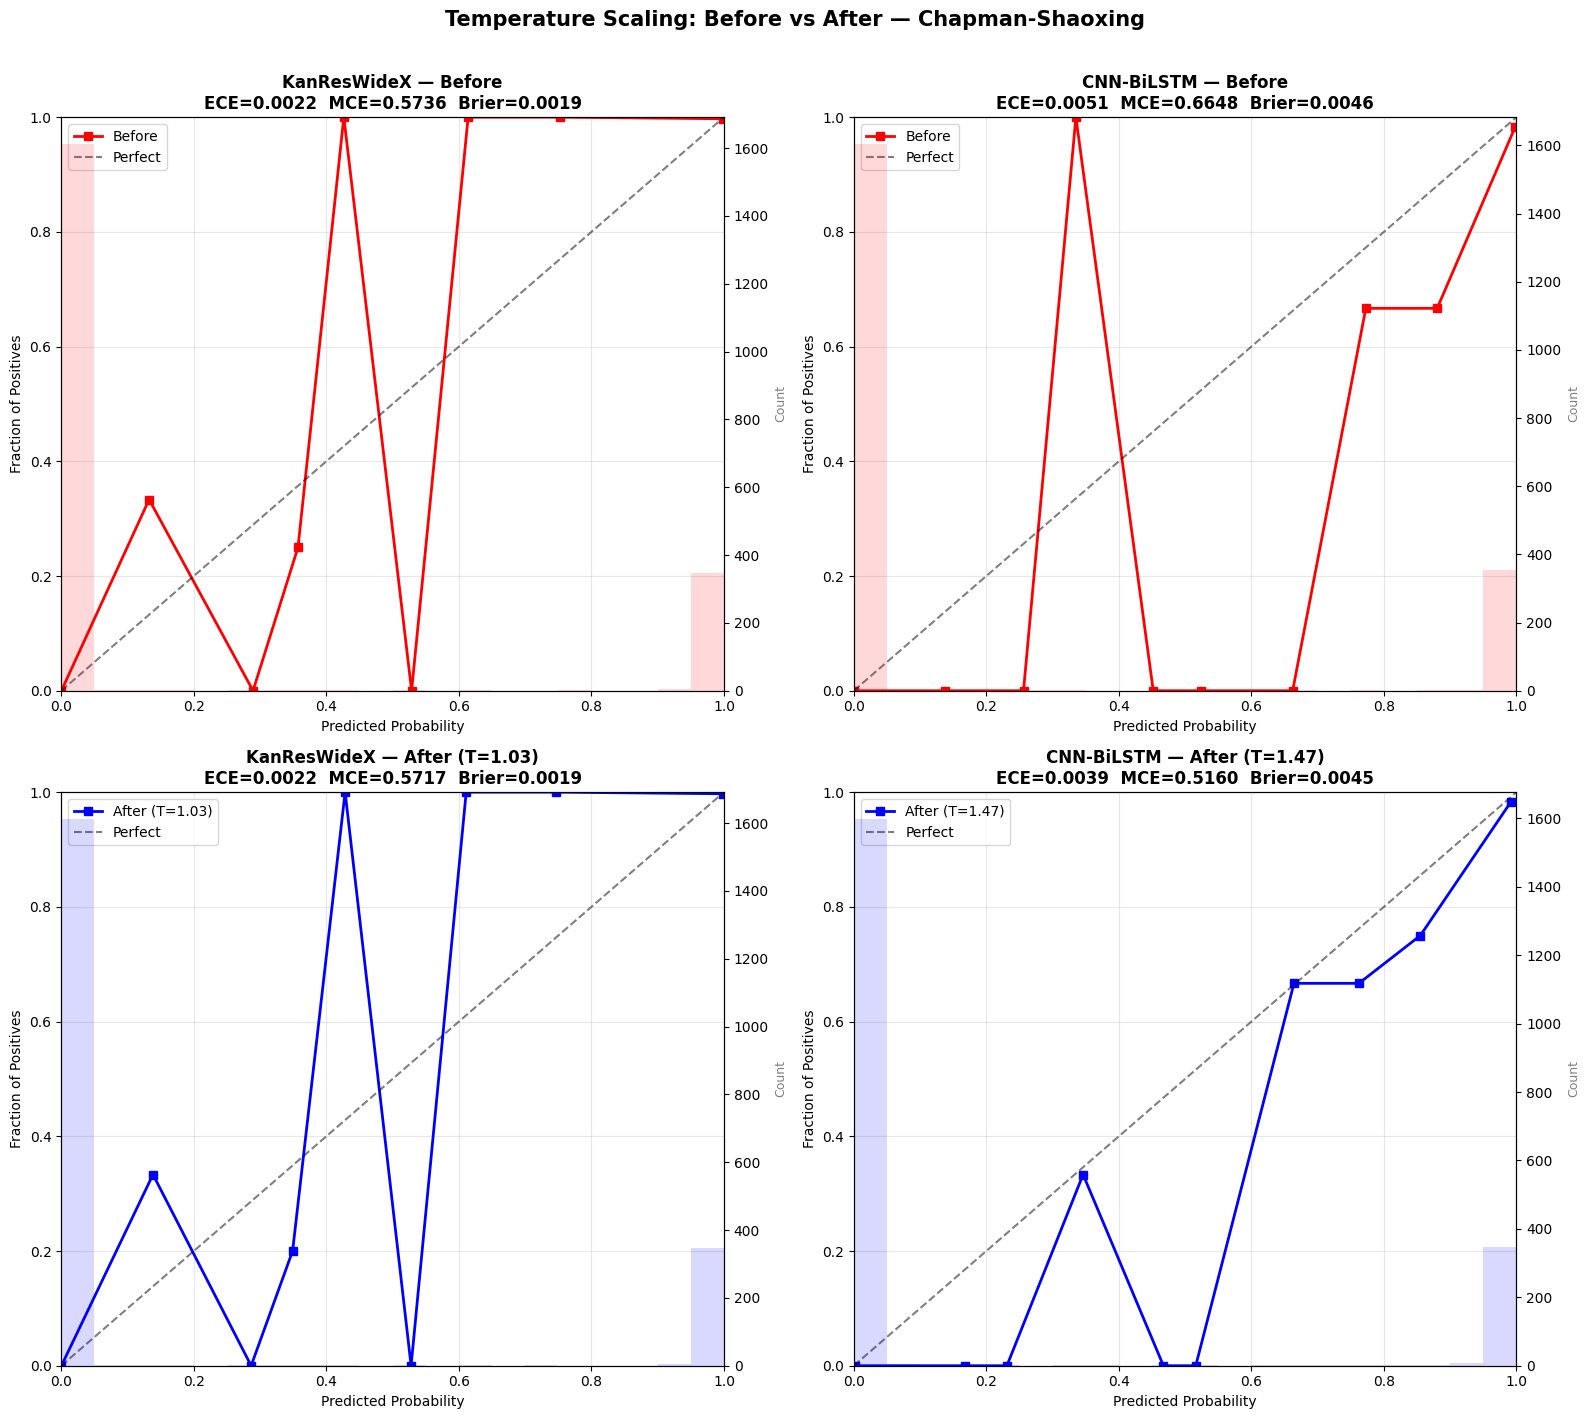

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col, model_name in enumerate(["KanResWideX", "CNN-BiLSTM"]):
    r = all_results[model_name]

    # Before
    ax = axes[0][col]
    frac, pred = calibration_curve(r["val_targets"], r["val_probs_before"], n_bins=10, strategy='uniform')
    ax.plot(pred, frac, 's-', color='red', linewidth=2, markersize=6, label='Before')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(r["val_probs_before"], bins=20, range=(0,1), alpha=0.15, color='red')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    b = r["chapman_before"]
    ax.set_title(f"{model_name} — Before\nECE={b['ece']:.4f}  MCE={b['mce']:.4f}  Brier={b['brier']:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left'); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)

    # After
    ax = axes[1][col]
    frac, pred = calibration_curve(r["val_targets"], r["val_probs_after"], n_bins=10, strategy='uniform')
    ax.plot(pred, frac, 's-', color='blue', linewidth=2, markersize=6, label=f'After (T={r["T"]:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
    ax2 = ax.twinx()
    ax2.hist(r["val_probs_after"], bins=20, range=(0,1), alpha=0.15, color='blue')
    ax2.set_ylabel('Count', fontsize=9, alpha=0.5)
    a = r["chapman_after"]
    ax.set_title(f"{model_name} — After (T={r['T']:.2f})\nECE={a['ece']:.4f}  MCE={a['mce']:.4f}  Brier={a['brier']:.4f}", fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Fraction of Positives')
    ax.legend(loc='upper left'); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)

plt.suptitle("Temperature Scaling: Before vs After — Chapman-Shaoxing", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ts_calibration_chapman.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 10. Probability Distributions: Before vs After

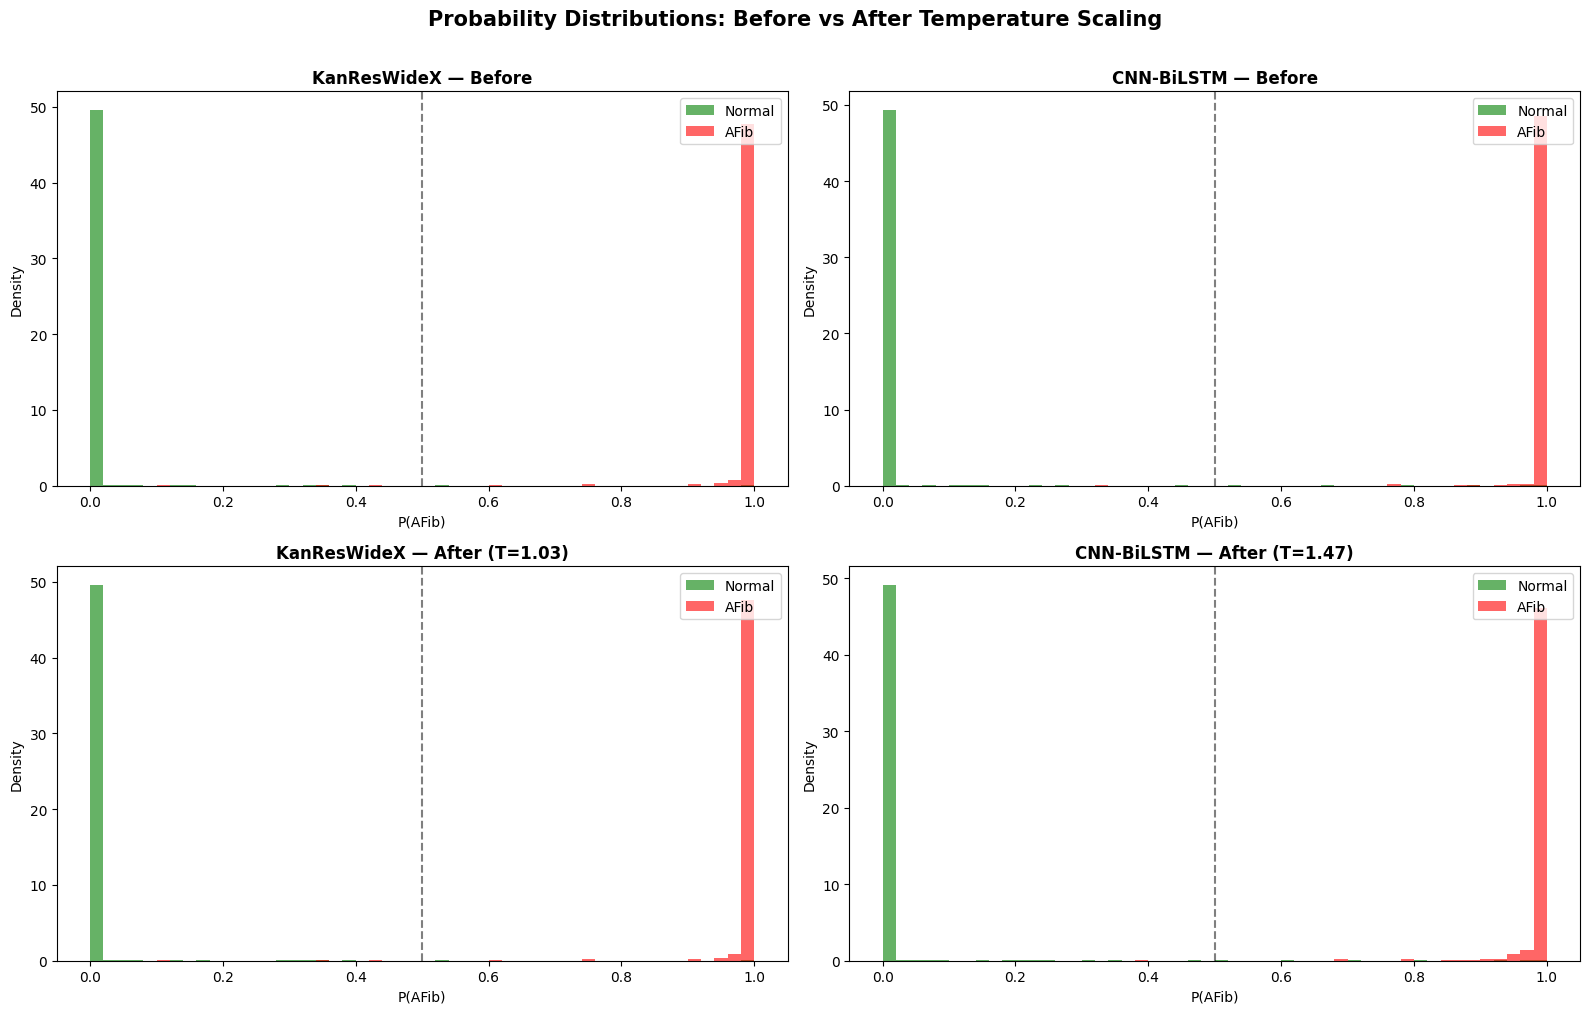

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, model_name in enumerate(["KanResWideX", "CNN-BiLSTM"]):
    r = all_results[model_name]
    for row, (probs, label) in enumerate([(r["val_probs_before"], "Before"), (r["val_probs_after"], f"After (T={r['T']:.2f})")]):
        ax = axes[row][col]
        ax.hist(probs[r["val_targets"]==0], bins=50, range=(0,1), alpha=0.6, color='green', label='Normal', density=True)
        ax.hist(probs[r["val_targets"]==1], bins=50, range=(0,1), alpha=0.6, color='red', label='AFib', density=True)
        ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
        ax.set_title(f"{model_name} — {label}", fontsize=12, fontweight='bold')
        ax.set_xlabel("P(AFib)"); ax.set_ylabel("Density"); ax.legend()

plt.suptitle("Probability Distributions: Before vs After Temperature Scaling", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ts_prob_dist_chapman.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 11. Load Cross-Dataset Data (PTB-XL + Georgia)

In [12]:
def load_cross_dataset(afib_dir, normal_dir, config, name):
    afib_f = sorted([f[:-4] for f in os.listdir(afib_dir) if f.endswith('.hea')])
    norm_f = sorted([f[:-4] for f in os.listdir(normal_dir) if f.endswith('.hea')])
    recs = [{"path": os.path.join(afib_dir, n), "name": n, "label": 1} for n in afib_f]
    recs += [{"path": os.path.join(normal_dir, n), "name": n, "label": 0} for n in norm_f]
    samples, labels, skipped = [], [], 0
    for rec in recs:
        s, l = load_record(rec, config)
        if s is not None: samples.append(s); labels.append(l)
        else: skipped += 1
    samples = np.array(samples, dtype=np.float32)
    labels = np.array(labels, dtype=np.int64)
    print(f"{name}: {len(labels)} loaded (AFib={np.sum(labels==1)}, Normal={np.sum(labels==0)}, skipped={skipped})")
    return samples, labels

# Unzip PTB-XL
if not os.path.exists("/content/ptbxl_data"):
    print("Unzipping PTB-XL...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/ptbxl_afib_normal_subset.zip" -d /content/ptbxl_data/
ptbxl_a, ptbxl_n = "", ""
for b in ["/content/ptbxl_data", "/content/ptbxl_data/ptbxl_afib_normal_subset"]:
    if os.path.exists(os.path.join(b, "afib")): ptbxl_a, ptbxl_n = os.path.join(b,"afib"), os.path.join(b,"normal"); break

# Unzip Georgia
if not os.path.exists("/content/georgia_data"):
    print("Unzipping Georgia...")
    !unzip -q "/content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/data/georgia_afib_normal_subset.zip" -d /content/georgia_data/
georgia_a, georgia_n = "", ""
for b in ["/content/georgia_data", "/content/georgia_data/georgia_afib_normal_subset"]:
    if os.path.exists(os.path.join(b, "afib")): georgia_a, georgia_n = os.path.join(b,"afib"), os.path.join(b,"normal"); break

# Fix Georgia .hea files
fixed = 0
for folder in [georgia_a, georgia_n]:
    if not folder: continue
    for fname in os.listdir(folder):
        if fname.endswith('.hea'):
            fpath = os.path.join(folder, fname)
            with open(fpath, 'r') as f: lines = f.readlines()
            parts = lines[0].strip().split()
            lines[0] = f"{parts[0].replace('.mat','')} {parts[1]} {parts[2]} {parts[3]}\n"
            with open(fpath, 'w') as f: f.writelines(lines)
            fixed += 1
print(f"Fixed {fixed} Georgia .hea files")

X_ptbxl, y_ptbxl = load_cross_dataset(ptbxl_a, ptbxl_n, config, "PTB-XL")
X_georgia, y_georgia = load_cross_dataset(georgia_a, georgia_n, config, "Georgia")

Unzipping PTB-XL...
Unzipping Georgia...
Fixed 2322 Georgia .hea files
PTB-XL: 10954 loaded (AFib=1477, Normal=9477, skipped=0)
Georgia: 2321 loaded (AFib=570, Normal=1751, skipped=1)


## 12. Cross-Dataset: Before vs After Temperature Scaling

In [13]:
cross_results = {}

for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    model = all_results[model_name]["model"]
    T = all_results[model_name]["T"]
    cross_results[model_name] = {}

    for ds_name, X, y in [("PTB-XL", X_ptbxl, y_ptbxl), ("Georgia", X_georgia, y_georgia)]:
        loader = DataLoader(ECGDataset(X, y), batch_size=config.batch_size, shuffle=False, num_workers=2, pin_memory=True)
        logits, labels = get_logits_and_labels(model, loader, device)
        targets = labels.numpy()

        probs_before = torch.softmax(logits, dim=1)[:, 1].numpy()
        probs_after = apply_temperature(logits, T)
        preds_before = (probs_before >= 0.5).astype(int)
        preds_after = (probs_after >= 0.5).astype(int)

        m_before = compute_all_metrics(targets, preds_before, probs_before)
        m_after = compute_all_metrics(targets, preds_after, probs_after)

        cross_results[model_name][ds_name] = {
            "before": m_before, "after": m_after,
            "probs_before": probs_before, "probs_after": probs_after,
            "targets": targets, "T": T
        }

        print(f"{model_name} on {ds_name} (T={T:.4f}):")
        print(f"  Acc:   {m_before['accuracy']:.4f} -> {m_after['accuracy']:.4f}")
        print(f"  ECE:   {m_before['ece']:.4f} -> {m_after['ece']:.4f}")
        print(f"  MCE:   {m_before['mce']:.4f} -> {m_after['mce']:.4f}")
        print(f"  Brier: {m_before['brier']:.4f} -> {m_after['brier']:.4f}")
        print()

KanResWideX on PTB-XL (T=1.0275):
  Acc:   0.9900 -> 0.9900
  ECE:   0.0063 -> 0.0061
  MCE:   0.2740 -> 0.2726
  Brier: 0.0080 -> 0.0080

KanResWideX on Georgia (T=1.0275):
  Acc:   0.9526 -> 0.9526
  ECE:   0.0464 -> 0.0464
  MCE:   0.8746 -> 0.7114
  Brier: 0.0446 -> 0.0446

CNN-BiLSTM on PTB-XL (T=1.4717):
  Acc:   0.9907 -> 0.9907
  ECE:   0.0069 -> 0.0049
  MCE:   0.1612 -> 0.2130
  Brier: 0.0084 -> 0.0083

CNN-BiLSTM on Georgia (T=1.4717):
  Acc:   0.9449 -> 0.9449
  ECE:   0.0489 -> 0.0439
  MCE:   0.5582 -> 0.5163
  Brier: 0.0496 -> 0.0476



## 13. Cross-Dataset Calibration Plots: Before vs After

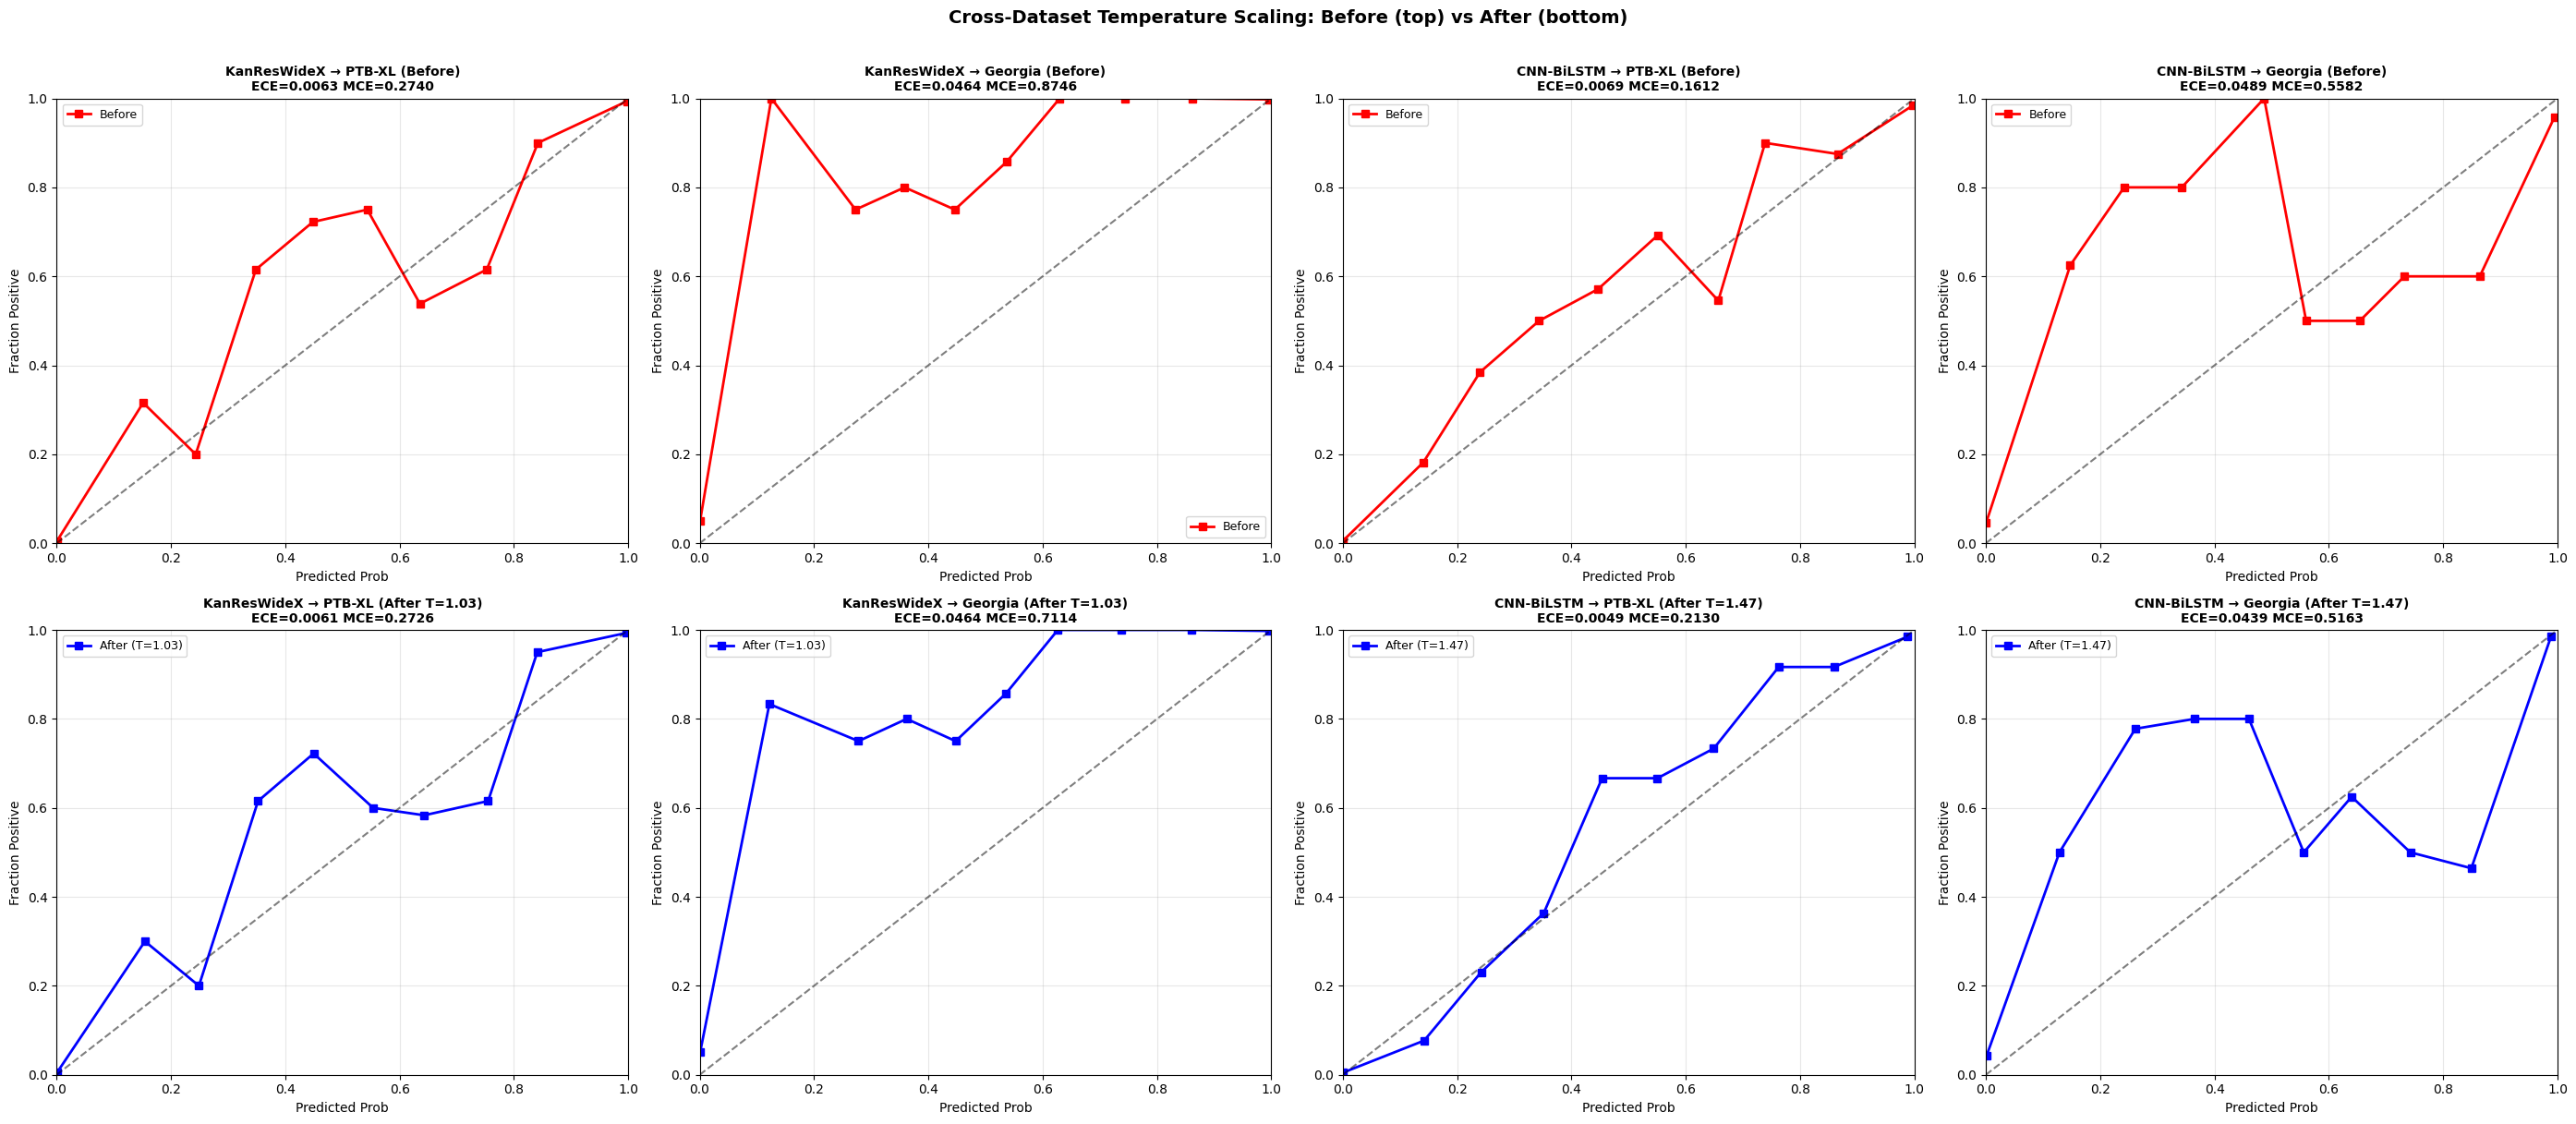

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))

col = 0
for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    for ds_name in ["PTB-XL", "Georgia"]:
        cr = cross_results[model_name][ds_name]

        # Before
        ax = axes[0][col]
        frac, pred = calibration_curve(cr["targets"], cr["probs_before"], n_bins=10, strategy='uniform')
        ax.plot(pred, frac, 's-', color='red', linewidth=2, markersize=6, label='Before')
        ax.plot([0,1], [0,1], 'k--', alpha=0.5)
        b = cr["before"]
        ax.set_title(f"{model_name} → {ds_name} (Before)\nECE={b['ece']:.4f} MCE={b['mce']:.4f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted Prob'); ax.set_ylabel('Fraction Positive')
        ax.legend(fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)

        # After
        ax = axes[1][col]
        frac, pred = calibration_curve(cr["targets"], cr["probs_after"], n_bins=10, strategy='uniform')
        ax.plot(pred, frac, 's-', color='blue', linewidth=2, markersize=6, label=f'After (T={cr["T"]:.2f})')
        ax.plot([0,1], [0,1], 'k--', alpha=0.5)
        a = cr["after"]
        ax.set_title(f"{model_name} → {ds_name} (After T={cr['T']:.2f})\nECE={a['ece']:.4f} MCE={a['mce']:.4f}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted Prob'); ax.set_ylabel('Fraction Positive')
        ax.legend(fontsize=9); ax.set_xlim([0,1]); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3)
        col += 1

plt.suptitle("Cross-Dataset Temperature Scaling: Before (top) vs After (bottom)", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(config.pdf_dir, "ts_calibration_cross_dataset.pdf"), format="pdf", bbox_inches="tight", dpi=300)
plt.show()

## 14. Complete Summary Table

In [15]:
print("=" * 110)
print("COMPLETE TEMPERATURE SCALING SUMMARY")
print("=" * 110)
print(f"\n{'Model':<15} {'Dataset':<20} {'T':<8} {'ECE Before':<12} {'ECE After':<12} {'MCE Before':<12} {'MCE After':<12} {'Brier Before':<14} {'Brier After'}")
print("-" * 110)

for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    r = all_results[model_name]
    T = r["T"]
    b, a = r["chapman_before"], r["chapman_after"]
    print(f"{model_name:<15} {'Chapman (Val)':<20} {T:<8.4f} {b['ece']:<12.4f} {a['ece']:<12.4f} {b['mce']:<12.4f} {a['mce']:<12.4f} {b['brier']:<14.4f} {a['brier']:.4f}")

    for ds in ["PTB-XL", "Georgia"]:
        cr = cross_results[model_name][ds]
        b, a = cr["before"], cr["after"]
        print(f"{'':<15} {ds:<20} {T:<8.4f} {b['ece']:<12.4f} {a['ece']:<12.4f} {b['mce']:<12.4f} {a['mce']:<12.4f} {b['brier']:<14.4f} {a['brier']:.4f}")

print("=" * 110)

print("\nAccuracy preservation:")
for model_name in ["KanResWideX", "CNN-BiLSTM"]:
    r = all_results[model_name]
    print(f"  {model_name} Chapman: {r['chapman_before']['accuracy']:.4f} -> {r['chapman_after']['accuracy']:.4f}")
    for ds in ["PTB-XL", "Georgia"]:
        cr = cross_results[model_name][ds]
        print(f"  {model_name} {ds}: {cr['before']['accuracy']:.4f} -> {cr['after']['accuracy']:.4f}")

COMPLETE TEMPERATURE SCALING SUMMARY

Model           Dataset              T        ECE Before   ECE After    MCE Before   MCE After    Brier Before   Brier After
--------------------------------------------------------------------------------------------------------------
KanResWideX     Chapman (Val)        1.0275   0.0022       0.0022       0.5736       0.5717       0.0019         0.0019
                PTB-XL               1.0275   0.0063       0.0061       0.2740       0.2726       0.0080         0.0080
                Georgia              1.0275   0.0464       0.0464       0.8746       0.7114       0.0446         0.0446
CNN-BiLSTM      Chapman (Val)        1.4717   0.0051       0.0039       0.6648       0.5160       0.0046         0.0045
                PTB-XL               1.4717   0.0069       0.0049       0.1612       0.2130       0.0084         0.0083
                Georgia              1.4717   0.0489       0.0439       0.5582       0.5163       0.0496         0.0476

Accur

## 15. Saved PDFs

In [16]:
print(f"\nPDF plots saved in: {config.pdf_dir}")
for f in sorted(os.listdir(config.pdf_dir)):
    if f.endswith('.pdf'):
        print(f"  {f}")


PDF plots saved in: /content/drive/Othercomputers/Min_PC/Skrivebord/Afib-Master/plots_pdf_temperature_scaling
  ts_calibration_chapman.pdf
  ts_calibration_cross_dataset.pdf
  ts_prob_dist_chapman.pdf
